In [54]:
# Import libraries
try:
    import ollama
    import sqlite3
    import pandas as pd
    import matplotlib.pyplot as plt
    import io
    import base64
    from IPython.display import display, Image, Markdown
    import ipywidgets as widgets
    from datetime import datetime, timedelta
    import re
    print("All modules installed properly.")

except ModuleNotFoundError as module_name: 
    print(f"the module {module_name} wasn't found")
    

All modules installed properly.


In [55]:
import ollama
import re

class OllamaLLM:
    """A class to interact with local Ollama models."""
    def __init__(self, sql_model='qwen3:4b', reasoning_model='gemma3:4b'):
        self.sql_model = sql_model
        self.reasoning_model = reasoning_model
        print(f"LLM handler initialized. Using '{self.sql_model}' for SQL and '{self.reasoning_model}' for reasoning.")

    def ask_for_confirmation(self, query, schema):
        # This function is stable.
        prompt = f"""
        You are an expert assistant. Your job is to paraphrase the user's request about oceanography data into a clear, single-sentence confirmation question.
        The confirmation question should be like: This is the thing you want is that correct?
        The database schema is: {schema}
        User's request: "{query}"
        Confirmation Question:
        """
        response = ollama.chat(model=self.reasoning_model, messages=[{'role': 'user', 'content': prompt}])
        return response['message']['content'].strip()

    def classify_intent(self, history, new_query):
        """Classifies the user's intent based on the conversation history."""
        prompt = f"""
        You are an expert intent classifier. Your job is to determine what the user wants to do next.

        Here is the conversation history:
        {history}

        Here is the new user query: "{new_query}"

        Based on the new query, classify the user's intent into ONE of the following categories:
        - NEW_QUERY: The user is asking for a completely new set of data to be plotted (e.g., asking about a different parameter or starting over).
        - REFINE_QUERY: The user is asking for a modification of the previous query (e.g., a different sensor, a different time range).
        - ANALYZE_DATA: The user is asking a question that can be answered by calculating something from the data that was just shown (e.g., "what is the average?", "find the max value").
        - CLARIFY: The user is asking for more explanation about the current graph or data, without needing new data.

        Your response MUST be a single word from the list above.

        Intent:
        """
        response = ollama.chat(
            model=self.reasoning_model,
            messages=[{'role': 'user', 'content': prompt}]
        )
        return response['message']['content'].strip()

    def generate_sql(self, history, schema, available_params, available_sensors):
        """
    Generates SQL, now using a more robust parsing method to extract the final query.
    """
    # The prompt is excellent. No changes are needed here.
        prompt = f"""
    You are an expert SQLite generation bot. Your sole purpose is to convert a user's request into a single, valid SQLite query based on the provided context.

    ### Database Schema
    {schema}

    ### Available Data Values
    - The `parameter_name` column can contain: {available_params}
    - The `sensor_id` column can contain: {available_sensors}

    ### Conversation History
    {history}

    ### STRICT Rules for Generating the Query:
    1.  **Map to Available Values:** First, map the user's plain-language request (e.g., "saltiness") to the official `parameter_name` from the "Available Data Values" list (e.g., 'Salinity').
    2.  **Case-Insensitive WHERE Clause:** All string comparisons in the `WHERE` clause MUST be case-insensitive. Use the `LOWER()` function on the column and the lowercase version of the value from Rule #1. Example: `WHERE LOWER(parameter_name) = 'salinity'`.
    3.  **Column Selection:** The query MUST select the `timestamp` and `value` columns.
    4.  **Time Filtering Logic:**
        - If the user's time frame is measured in **days, weeks, or months** (e.g., "past 3 days", "last week"), use the `date()` function to start from the beginning of the day. Example: `WHERE timestamp >= date('now', '-3 days')`.
        - If the user's time frame is measured in **hours, minutes, or seconds** (e.g., "past 8 hours", "last 30 minutes"), use the `datetime()` function for a precise relative time. Example: `WHERE timestamp >= datetime('now', '-8 hours')`.
    5.  **Output Format:** Your final output MUST be only the raw SQLite query, ending in a semicolon. Do not include any explanations, comments, or markdown formatting.

    ### Final SQLite Query:
    """

        response = ollama.chat(model=self.sql_model, messages=[{'role': 'user', 'content': prompt}])
        raw_output = response['message']['content']

    # --- NEW, MORE ROBUST PARSING LOGIC ---
    # Find all occurrences of a complete SELECT statement ending in a semicolon.
        matches = re.findall(r"(SELECT .*?;)", raw_output, re.IGNORECASE | re.DOTALL)

        if matches:
        # The last match is the final, intended query.
            cleaned_sql = matches[-1].strip()
            return cleaned_sql
        else:
        # Fallback for safety, though the above should work.
            if "SELECT" in raw_output:
             # Take the part after the last "SELECT" as a guess
                last_part = raw_output.split("SELECT")[-1]
                cleaned_sql = "SELECT" + last_part.strip()
                if not cleaned_sql.endswith(';'):
                    cleaned_sql += ';'
                    return cleaned_sql
            raise ValueError("Could not extract a valid SQL query from the LLM's response.")


    def answer_from_data(self, df, question):
        """Uses the reasoning LLM to answer a question based on existing data."""
        if df is None or df.empty:
            return "There is no data to analyze."
        
        # Perform basic calculations and add them to the prompt for accuracy
        stats = ""
        if 'value' in df.columns:
            stats = f"""
            Here are some pre-calculated statistics from the data:
            - Average (mean): {df['value'].mean():.2f}
            - Maximum value: {df['value'].max():.2f}
            - Minimum value: {df['value'].min():.2f}
            - Number of data points: {len(df)}
            """

        prompt = f"""
        You are a helpful data analyst. A user has been shown a dataset and has a follow-up question.
        {stats}
        
        User's question: "{question}"
        
        Based on the statistics and the user's question, provide a concise, natural language answer.
        """
        response = ollama.chat(model=self.reasoning_model, messages=[{'role': 'user', 'content': prompt}])
        return response['message']['content']


    
    def explain_image(self, image_bytes, query):
        # This function is stable.
        prompt = f"""
        You are a marine science expert. Analyze the provided graph, which was generated for the query: "{query}".
        Describe the key trends, patterns, or significant anomalies.
        """
        response = ollama.chat(
            model=self.reasoning_model,
            messages=[{'role': 'user', 'content': prompt, 'images': [image_bytes]}]
        )
        return response['message']['content']

# Re-instantiate the class with the new logic
llm = OllamaLLM(sql_model='sqlqwen3:4b', reasoning_model='gemma3:4b')

LLM handler initialized. Using 'sqlqwen3:4b' for SQL and 'gemma3:4b' for reasoning.


In [56]:
class ConversationState:
    """A simple class to store the state of the conversation."""
    def __init__(self):
        self.conversation_history = []
        self.last_df = None
        self.last_sql_query = ""

    def add_message(self, role, content):
        """Adds a message to the conversation history."""
        self.conversation_history.append({"role": role, "content": content})

    def get_history_string(self):
        """Returns the conversation history as a formatted string."""
        if not self.conversation_history:
            return "No history yet."
        return "\n".join([f"{msg['role'].capitalize()}: {msg['content']}" for msg in self.conversation_history])

    def clear(self):
        """Resets the conversation state."""
        self.conversation_history = []
        self.last_df = None
        self.last_sql_query = ""
        print("[State cleared]")

In [57]:
# Connect to an in-memory SQLite database
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Define the database schema
cursor.execute('''
CREATE TABLE sensor_data (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp DATETIME NOT NULL,
    sensor_id TEXT NOT NULL,
    parameter_name TEXT NOT NULL,
    depth_m INTEGER,
    value REAL NOT NULL
);
''')

# --- Generate Sample Data ---
def generate_data(sensor_id, param_name, depth, start_val, days):
    data = []
    current_time = datetime.now()
    for i in range(days * 24): # Hourly data
        timestamp = current_time - timedelta(hours=i)
        value = start_val + (i % 10) * 0.1 - 0.5 + (-1)**i * 0.2
        data.append((timestamp, sensor_id, param_name, depth, round(value, 2)))
    return data

# Populate with data
sensor_data = []
sensor_data.extend(generate_data('BD10', 'Salinity', 30, 35, 10))
sensor_data.extend(generate_data('BD10', 'Water Temperature', 30, 15, 10))
sensor_data.extend(generate_data('CB02', 'Air Pressure', None, 1012, 10))

cursor.executemany('INSERT INTO sensor_data (timestamp, sensor_id, parameter_name, depth_m, value) VALUES (?, ?, ?, ?, ?)', sensor_data)
conn.commit()

print("Database created and populated with sample data.")

# Define our schema as a string to pass to the LLM
db_schema = "Table: sensor_data, Columns: id, timestamp, sensor_id, parameter_name, depth_m, value"
# Query for distinct parameter names
params_df = pd.read_sql_query("SELECT DISTINCT parameter_name FROM sensor_data", conn)
available_parameters = params_df['parameter_name'].tolist()

# Query for distinct sensor IDs
sensors_df = pd.read_sql_query("SELECT DISTINCT sensor_id FROM sensor_data", conn)
available_sensors = sensors_df['sensor_id'].tolist()

# Create formatted strings to inject into our prompt
parameter_list_str = ", ".join(f"'{p}'" for p in available_parameters)
sensor_list_str = ", ".join(f"'{s}'" for s in available_sensors)

print("--- Data Dictionary Loaded ---")
print(f"Available Parameters: {parameter_list_str}")
print(f"Available Sensors: {sensor_list_str}")
print("-----------------------------")

Database created and populated with sample data.
--- Data Dictionary Loaded ---
Available Parameters: 'Salinity', 'Water Temperature', 'Air Pressure'
Available Sensors: 'BD10', 'CB02'
-----------------------------


C:\Users\This\AppData\Local\Temp\ipykernel_274964\2306935452.py:33: DeprecationWarning: The default datetime adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes
  cursor.executemany('INSERT INTO sensor_data (timestamp, sensor_id, parameter_name, depth_m, value) VALUES (?, ?, ?, ?, ?)', sensor_data)


In [58]:
#Helper functions (unchanged)
def execute_query(sql_query):
    try:
        df = pd.read_sql_query(sql_query, conn)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        return df.sort_values(by='timestamp')
    except Exception as e:
        print(f"An error occurred during SQL execution: {e}")
        return None

def plot_data(df, title):
    if df is None or df.empty: return None
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df['timestamp'], df['value'], marker='.', linestyle='-')
    ax.set_title(title)
    ax.grid(True)
    plt.xticks(rotation=15)
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    image_bytes = buf.getvalue()
    buf.close()
    plt.close(fig)
    return image_bytes

# --- Main Application ---
llm = OllamaLLM()
state = ConversationState()

def handle_new_or_refine_query(state):
    """Handles the logic for fetching, plotting, and explaining new data."""
    try:
        print("\n🤖 Generating SQL...")
        # --- UPDATE THIS LINE ---
        sql_query = llm.generate_sql(state.get_history_string(), db_schema, parameter_list_str, sensor_list_str)
        # ---
        
        state.last_sql_query = sql_query
        display(Markdown(f"**Generated SQL:** `{sql_query}`"))

        # 2. Execute Query
        print("Executing query...")
        data_df = execute_query(sql_query)
        state.last_df = data_df

        if data_df is None or data_df.empty:
            display(Markdown("⚠️ **Warning:** The query returned no data. Please try a different query."))
            state.add_message("assistant", "I couldn't find any data for that request. Can you try asking something else?")
            return

        # 3. Plot Data
        print("Plotting data...")
        image_bytes = plot_data(data_df, state.conversation_history[-1]['content'])
        
        # 4. Get Explanation
        print("Generating explanation...")
        explanation = llm.explain_image(image_bytes, state.conversation_history[-1]['content'])

        # 5. Display Results
        display(Markdown("---"))
        display(Image(data=image_bytes))
        display(Markdown(f"**Explanation:** {explanation}"))
        state.add_message("assistant", explanation)

    except Exception as e:
        print(f"An error occurred: {e}")
        state.add_message("assistant", f"I encountered an error: {e}")

def chat():
    """Main chat loop for the application."""
    print("🌊 Welcome to the Oceanography Data Chatbot! Type 'quit' to exit.")
    while True:
        #print("entered the loop")
        user_query = input("\nYou: ")
        if user_query.lower() in ['quit', 'exit']:
            print("Goodbye!")
            break
        
        state.add_message("user", user_query)
        print("User Query=",user_query)
        # 1. Classify Intent
        print("🤖 Classifying intent...")
        intent = llm.classify_intent(state.get_history_string(), user_query)
        display(Markdown(f"**Detected Intent:** `{intent}`"))

        # 2. Route to appropriate handler
        if intent == "NEW_QUERY":
            # For a new query, we can optionally clear the past context
            # state.clear()
            # state.add_message("user", user_query)
            handle_new_or_refine_query(state)
        
        elif intent == "REFINE_QUERY":
            handle_new_or_refine_query(state)

        elif intent == "ANALYZE_DATA":
            print("🤖 Answering from existing data...")
            answer = llm.answer_from_data(state.last_df, user_query)
            display(Markdown(f"**Answer:** {answer}"))
            state.add_message("assistant", answer)
        
        elif intent == "CLARIFY":
            # This can be a more sophisticated handler, but for now, we'll treat it like ANALYZE
            print("🤖 Clarifying from existing data...")
            answer = llm.answer_from_data(state.last_df, user_query)
            display(Markdown(f"**Answer:** {answer}"))
            state.add_message("assistant", answer)
        
        else:
            display(Markdown("I'm not sure how to handle that. Please try rephrasing your question."))
            state.add_message("assistant", "I'm not sure how to handle that.")

# Start the chat application


LLM handler initialized. Using 'qwen3:4b' for SQL and 'gemma3:4b' for reasoning.


🌊 Welcome to the Oceanography Data Chatbot! Type 'quit' to exit.
🤖 Classifying intent...


**Detected Intent:** `REFINE_QUERY`


🤖 Generating SQL...


**Generated SQL:** `SELECT timestamp, value FROM sensor_data WHERE LOWER(parameter_name) = 'air pressure' AND LOWER(sensor_id) = 'bd10' AND timestamp >= datetime('now', '-30 hours');`

Executing query...


...

**Detected Intent:** `REFINE_QUERY`


🤖 Generating SQL...


**Generated SQL:** `SELECT timestamp, value
FROM sensor_data
WHERE LOWER(parameter_name) = 'salinity'
  AND sensor_id = 'BD10'
  AND timestamp >= date('now', '-2 days');`

Executing query...
Plotting data...
Generating explanation...


---

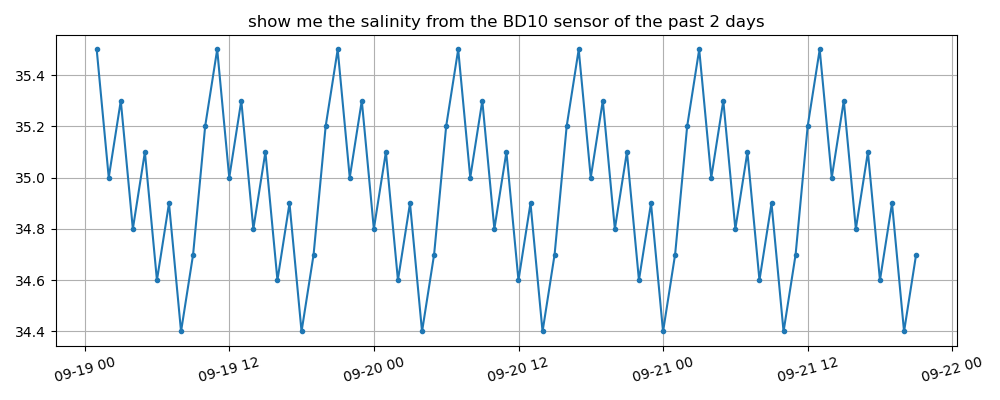

**Explanation:** Okay, let’s analyze this salinity data from the BD10 sensor over the past two days. 

**Overall Trend:**

The most prominent feature of this data is a clear, cyclical pattern. The salinity exhibits a regular fluctuation, oscillating around a central value.

**Specific Observations & Patterns:**

* **Cyclical Fluctuations:** The salinity values consistently rise and fall, suggesting a rhythmic process at play. The cycle appears to be relatively consistent across both days.
* **Peak Values:** The highest salinity readings occur around 35.2 - 35.3.
* **Troughs:** The lowest salinity readings are observed at approximately 34.6.
* **Consistent Cycle Length:** It appears the cycle length (the time it takes to go from a high to a low and back to a high) is roughly consistent. 

**Possible Interpretations (Without additional context, this is speculative):**

* **Tidal Influence:** The cyclical nature strongly suggests a link to tidal patterns. As tides rise and fall, salinity can change due to the influx and outflow of freshwater. 
* **River Runoff:**  The salinity fluctuations may also be influenced by river discharge, where freshwater mixing with seawater can alter salinity levels. 
* **Wind Patterns:** Wind patterns can affect seawater movement and salinity distribution.

**Important Note:** To provide a more detailed and accurate interpretation, it would be valuable to know:

*   **Location:**  Where is this BD10 sensor located? (e.g., coastal region, estuary, open ocean)
*   **Sensor Specifications:** What is the sensor’s precision and measurement frequency?
*   **Other Relevant Data:** Are there concurrent measurements of water temperature, tide height, river discharge, or wind speed?

With more context, I could give you a much more robust analysis of the salinity fluctuations and what’s driving them. 



🤖 Classifying intent...


**Detected Intent:** `CLARIFY`

🤖 Clarifying from existing data...


**Answer:** Okay, let’s consider that scenario. With an average of 34.95, a maximum of 35.50, and a minimum of 34.40 across 69 data points, the fluctuation isn’t cyclic if the changes we’re seeing are purely random variations. It would suggest the data is exhibiting natural, unpredictable variability – perhaps due to inherent noise in the system being measured, or simply random chance.  A cyclical pattern would imply a repeating, predictable pattern, and these statistics don’t indicate that.

...


🤖 Generating SQL...


**Generated SQL:** `SELECT timestamp, value FROM sensor_data WHERE LOWER(parameter_name) = 'air pressure' AND LOWER(sensor_id) = 'bd10' AND timestamp >= date('now', '-4 days');`

Executing query...


⚠️ **Warning:** The query returned no data. Please try a different query.

Goodbye!


In [59]:
chat()
